<a href="https://colab.research.google.com/github/maulidyaafriani/Pembelajaran-Mesin-2026/blob/main/TG4_244107020059_MAULIDYA_AFRIANI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PRAKTIKUM 1**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

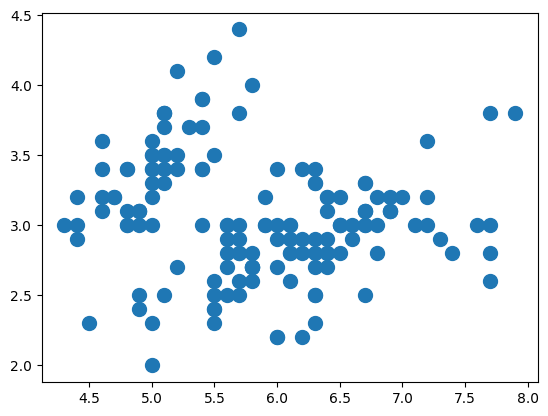

In [6]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [7]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

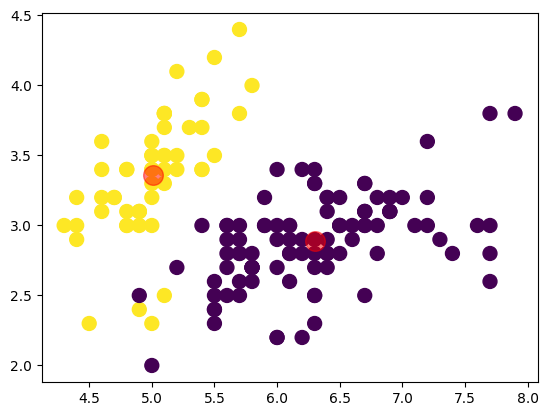

In [8]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [9]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


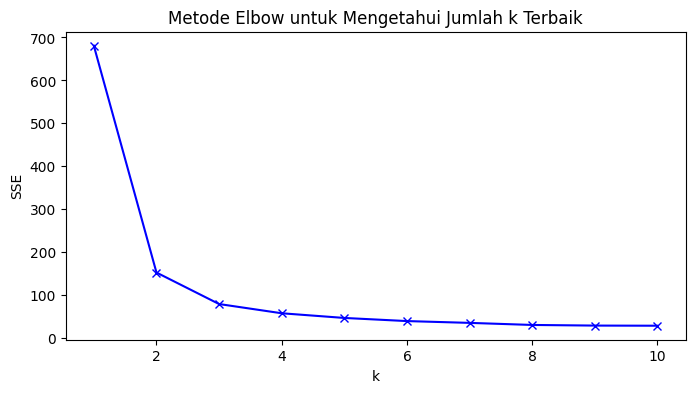

In [11]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1, 11)

# Cek nilai SSE setiap k
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

# Plotting SSE
plt.figure(figsize=(8, 4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [12]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.44028021295475
k=5; SSE=46.535582051282034
k=6; SSE=39.251830892636775
k=7; SSE=35.04275995246584
k=8; SSE=30.217021122152712
k=9; SSE=28.7564561965812
k=10; SSE=28.424891802641817


**PRAKTIKUM 2**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

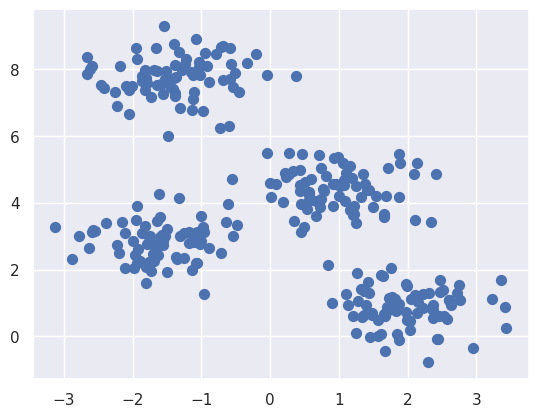

In [14]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

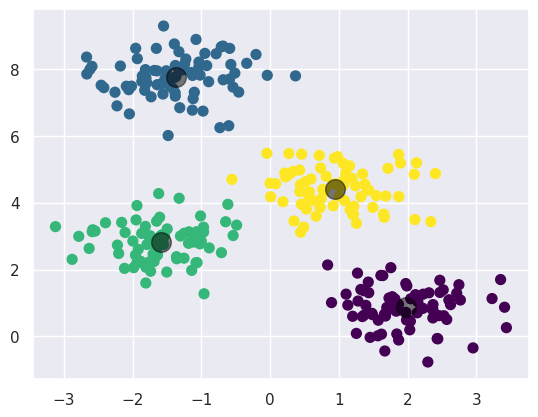

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

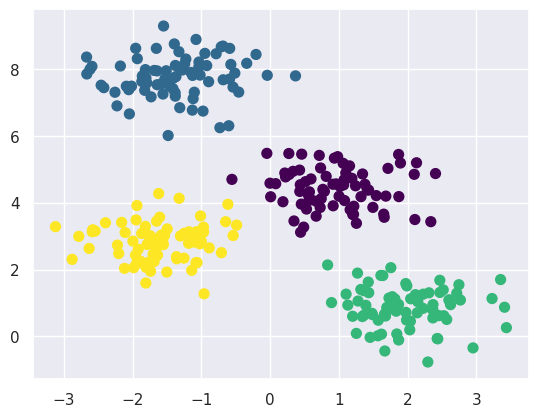

In [17]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

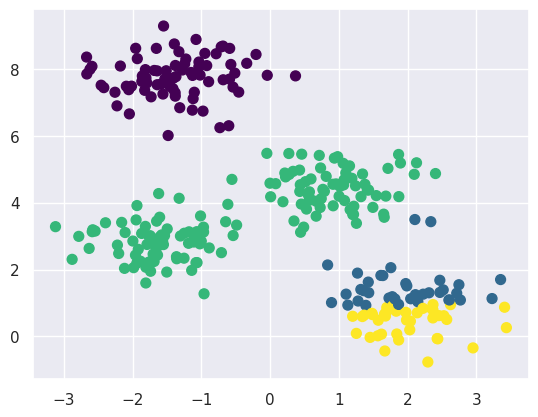

In [18]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

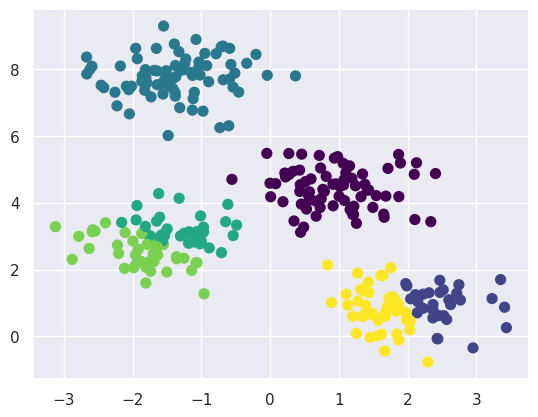

In [19]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [20]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

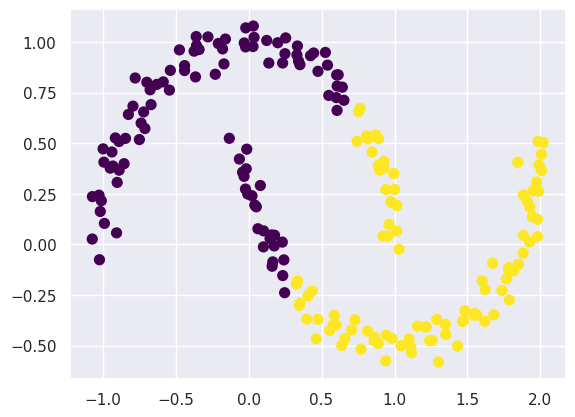

In [21]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


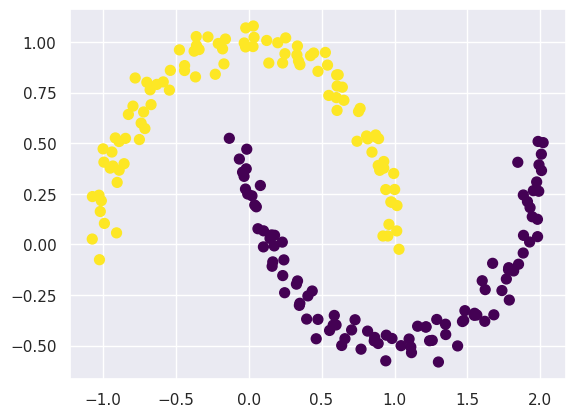

In [22]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [23]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [24]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

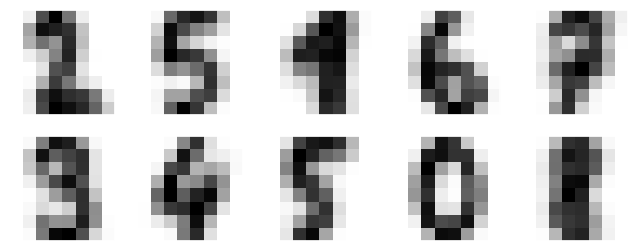

In [25]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [26]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

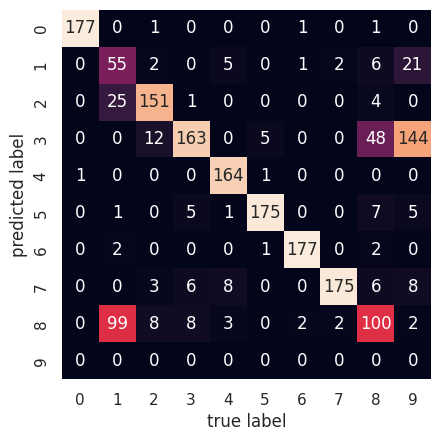

In [28]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [29]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

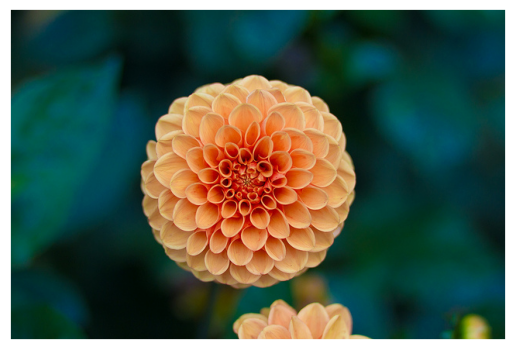

In [30]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [31]:
flower.shape

(427, 640, 3)

In [32]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [33]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

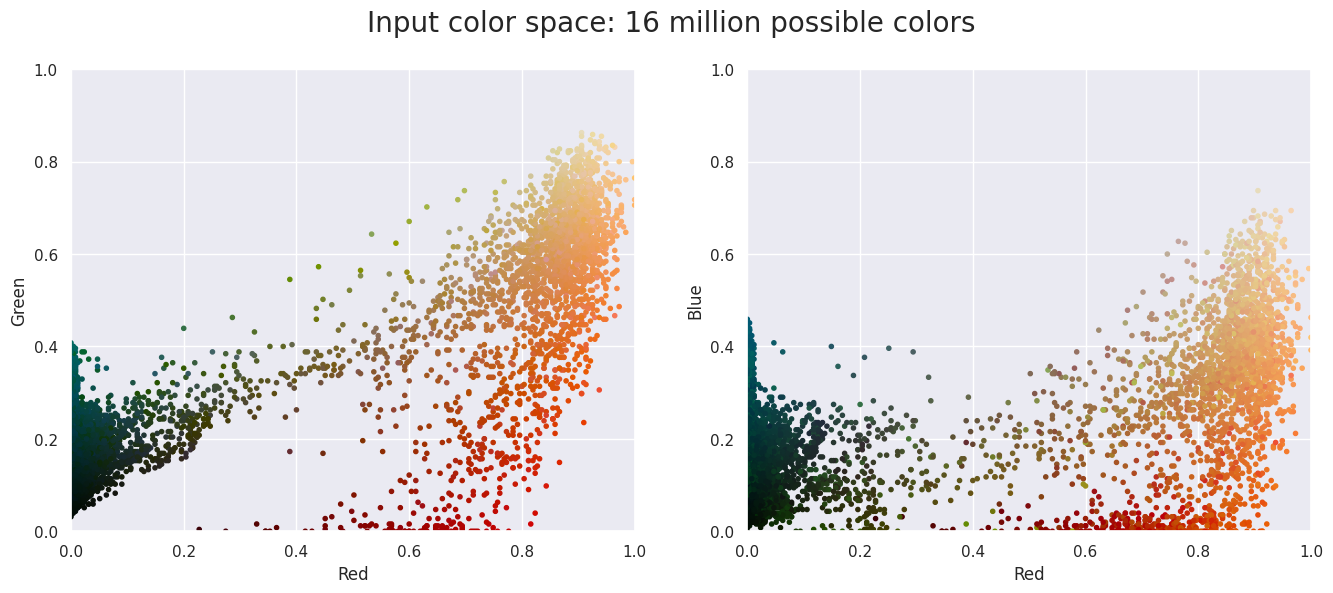

In [34]:
plot_pixels(data, title='Input color space: 16 million possible colors')

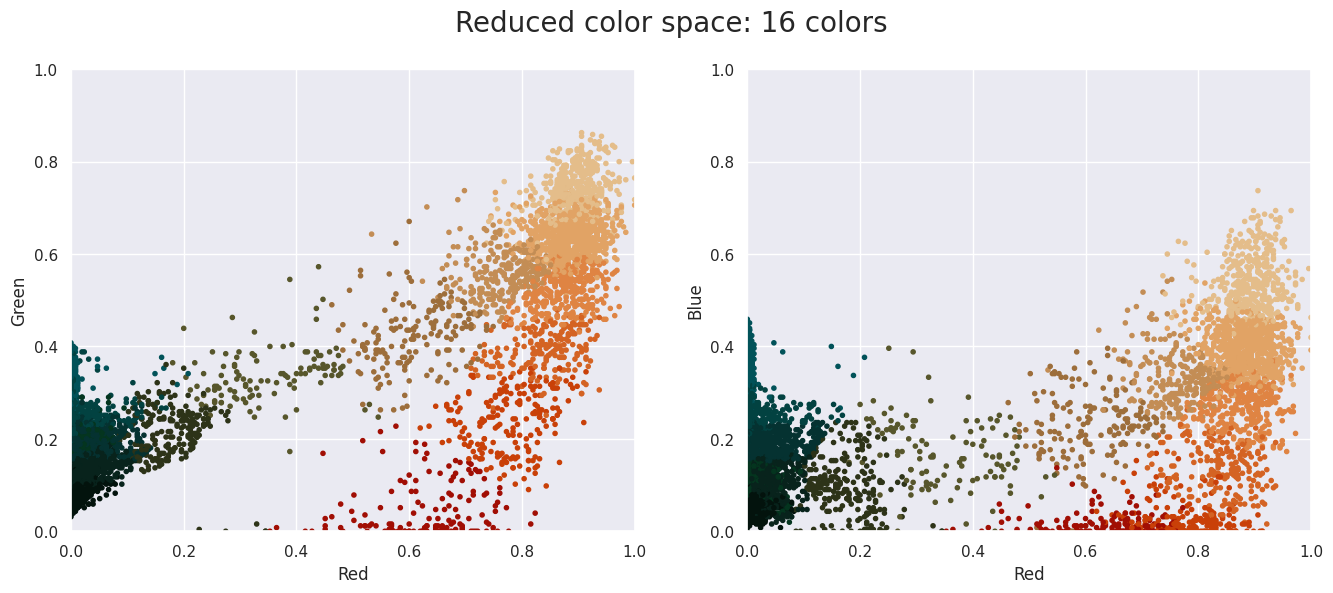

In [35]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

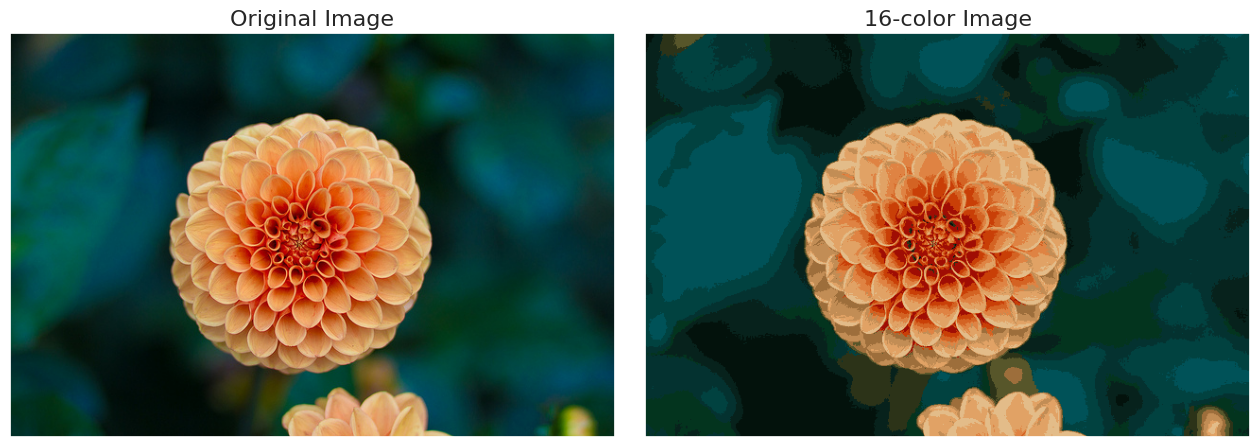

In [36]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

**Praktikum 3**

In [38]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

In [39]:
import matplotlib.pyplot as plt

(X[:, 0], X[:, 1])
()

()

In [41]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


In [43]:
from sklearn import metrics

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


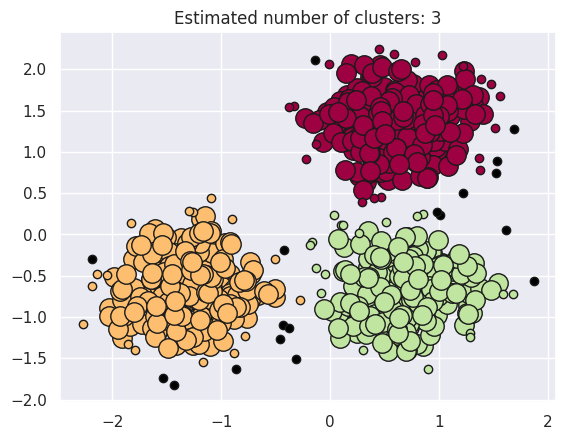

In [47]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

**Tugas Praktikum**


1. Tugas K-Means

In [48]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn import metrics
from sklearn.datasets import make_moons

In [50]:
df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.shape)
print(df.isna().sum())
print(df.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41

In [51]:
fitur = ["Annual Income (k$)", "Spending Score (1-100)"]
X = StandardScaler().fit_transform(df[fitur])

SSE: [269.7, 157.7, 108.9, 65.6, 55.1, 44.9, 37.2, 32.4, 30.0]
Silhouette: [np.float64(0.321), np.float64(0.467), np.float64(0.494), np.float64(0.555), np.float64(0.54), np.float64(0.528), np.float64(0.455), np.float64(0.457), np.float64(0.443)]


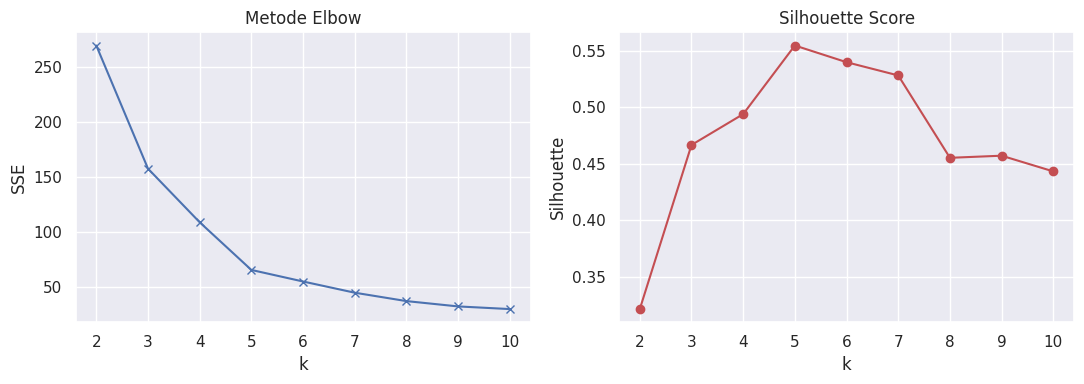

Silhouette k=5: 0.555
          Age  Annual Income (k$)  Spending Score (1-100)   n
Cluster                                                      
0        42.7                55.3                    49.5  81
1        32.7                86.5                    82.1  39
2        25.3                25.7                    79.4  22
3        41.1                88.2                    17.1  35
4        45.2                26.3                    20.9  23


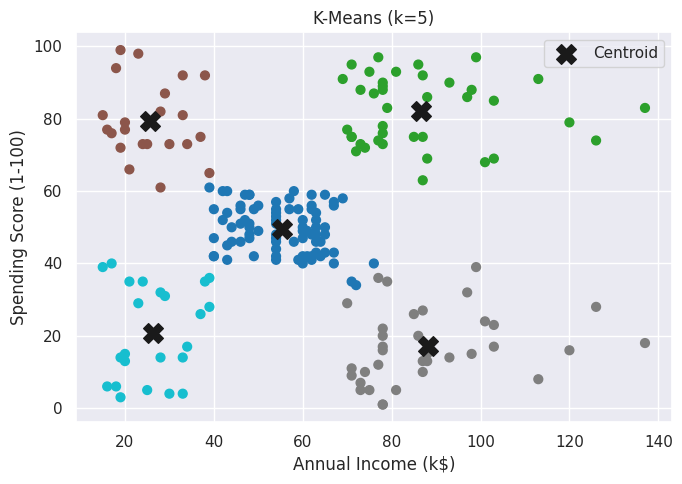


DBSCAN eps=0.2 min=5: {'clusters': 2, 'noise': 0, 'homog': np.float64(1.0), 'compl': np.float64(1.0), 'vmeas': np.float64(1.0), 'ari': 1.0, 'ami': np.float64(1.0), 'sil': np.float64(0.391)}


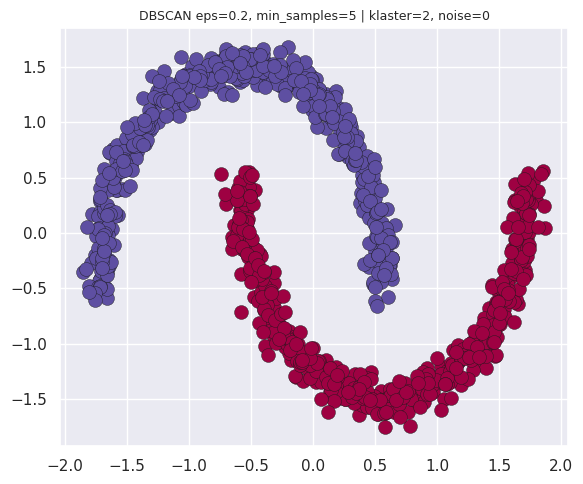

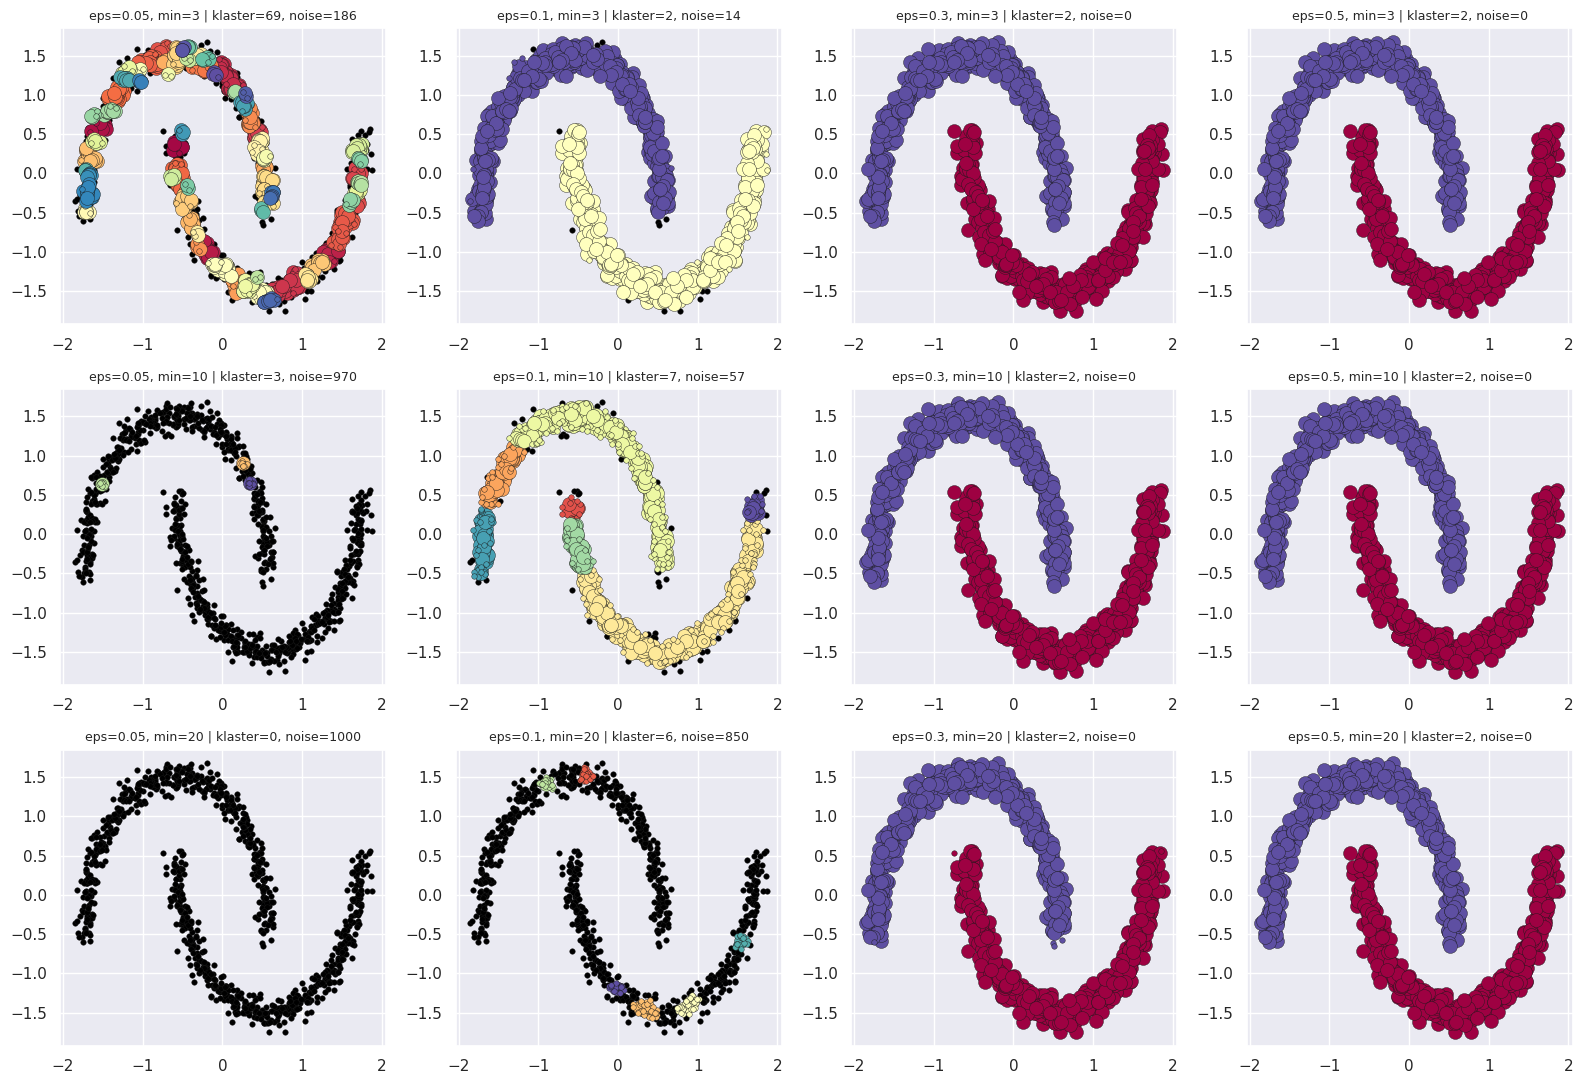

 eps  min_samples  clusters  noise  homog  compl  vmeas   ari   ami    sil
0.05            3        69    186  0.816  0.153  0.257 0.030 0.244  0.113
0.10            3         2     14  0.986  0.903  0.943 0.972 0.943  0.252
0.30            3         2      0  1.000  1.000  1.000 1.000 1.000  0.391
0.50            3         2      0  1.000  1.000  1.000 1.000 1.000  0.391
0.05           10         3    970  0.031  0.127  0.049 0.002 0.046 -0.294
0.10           10         7     57  0.943  0.410  0.571 0.523 0.570  0.162
0.30           10         2      0  1.000  1.000  1.000 1.000 1.000  0.391
0.50           10         2      0  1.000  1.000  1.000 1.000 1.000  0.391
0.05           20         0   1000  0.000  1.000  0.000 0.000 0.000    NaN
0.10           20         6    850  0.154  0.155  0.155 0.017 0.151 -0.360
0.30           20         2      0  1.000  1.000  1.000 1.000 1.000  0.391
0.50           20         2      0  1.000  1.000  1.000 1.000 1.000  0.391


In [52]:
import numpy as np, pandas as pd, matplotlib
pass
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn import metrics
from sklearn.datasets import make_moons
OUT=""

# ========== 1. K-MEANS ==========
df = pd.read_csv("Mall_Customers.csv")
# Pilih fitur: Annual Income & Spending Score
fitur = ["Annual Income (k$)", "Spending Score (1-100)"]
X = StandardScaler().fit_transform(df[fitur])

sse, sil = [], []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sse.append(km.inertia_); sil.append(silhouette_score(X, km.labels_))
print("SSE:", [round(s,1) for s in sse]); print("Silhouette:", [round(s,3) for s in sil])

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(K, sse, "bx-"); ax[0].set(xlabel="k", ylabel="SSE", title="Metode Elbow")
ax[1].plot(K, sil, "ro-"); ax[1].set(xlabel="k", ylabel="Silhouette", title="Silhouette Score")
plt.tight_layout(); plt.show()

best_k = 5
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
df["Cluster"] = km.labels_
print("Silhouette k=5:", round(silhouette_score(X, km.labels_),3))
print(df.groupby("Cluster")[["Age"]+fitur].mean().round(1).assign(n=df.Cluster.value_counts().sort_index()))
cent = StandardScaler().fit(df[fitur]).inverse_transform(km.cluster_centers_)
plt.figure(figsize=(7,5))
sc = plt.scatter(df[fitur[0]], df[fitur[1]], c=df.Cluster, cmap="tab10", s=40)
plt.scatter(cent[:,0], cent[:,1], c="k", marker="X", s=200, label="Centroid")
plt.xlabel(fitur[0]); plt.ylabel(fitur[1]); plt.title(f"K-Means (k={best_k})"); plt.legend()
plt.tight_layout(); plt.show()

# ========== 2. DBSCAN ==========
Xm, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
Xm = StandardScaler().fit_transform(Xm)

def evaluasi(labels):
    n_c = len(set(labels)) - (1 if -1 in labels else 0); n_n = list(labels).count(-1)
    r = dict(clusters=n_c, noise=n_n,
        homog=metrics.homogeneity_score(y_true, labels),
        compl=metrics.completeness_score(y_true, labels),
        vmeas=metrics.v_measure_score(y_true, labels),
        ari=metrics.adjusted_rand_score(y_true, labels),
        ami=metrics.adjusted_mutual_info_score(y_true, labels))
    r["sil"] = metrics.silhouette_score(Xm, labels) if n_c >= 2 else np.nan
    return r

def plot(db, labels, ax, title):
    mask = np.zeros_like(labels, dtype=bool); mask[db.core_sample_indices_] = True
    uniq = sorted(set(labels)); cols = [plt.cm.Spectral(e) for e in np.linspace(0,1,len(uniq))]
    for k, col in zip(uniq, cols):
        if k == -1: col = [0,0,0,1]
        m = labels == k
        for sel, ms in ((m & mask, 10), (m & ~mask, 4)):
            p = Xm[sel]; ax.plot(p[:,0], p[:,1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=ms, markeredgewidth=0.3)
    ax.set_title(title, fontsize=9)

db = DBSCAN(eps=0.2, min_samples=5).fit(Xm); labels = db.labels_
r = evaluasi(labels); print("\nDBSCAN eps=0.2 min=5:", {k:(round(v,3) if isinstance(v,float) else v) for k,v in r.items()})
fig, ax = plt.subplots(figsize=(6,5)); plot(db, labels, ax, f"DBSCAN eps=0.2, min_samples=5 | klaster={r['clusters']}, noise={r['noise']}")
plt.tight_layout(); plt.show()

rows=[]; eps_l=[0.05,0.1,0.3,0.5]; ms_l=[3,10,20]
fig, axes = plt.subplots(3,4, figsize=(16,11))
for i,m in enumerate(ms_l):
    for j,e in enumerate(eps_l):
        d = DBSCAN(eps=e, min_samples=m).fit(Xm); l = d.labels_
        r = evaluasi(l); rows.append(dict(eps=e, min_samples=m, **r))
        plot(d, l, axes[i,j], f"eps={e}, min={m} | klaster={r['clusters']}, noise={r['noise']}")
plt.tight_layout(); plt.show()
res = pd.DataFrame(rows).round(3); print(res.to_string(index=False))
res.to_csv(OUT+"dbscan_eksperimen.csv", index=False)
df.to_csv(OUT+"Mall_Customers_clustered.csv", index=False)